`Authors: Thomas Hill, Igor Kowalec`

An example script showing reading in files with ASE and invoking the MACE calculator

Make sure you have the following libraries installed in your virtual environment:
```
ase torch mace-torch torch-dftd
```

Load the necessary libraries

In [1]:
# to keep the notebook tidy, we will disable warnings
import warnings
warnings.filterwarnings("ignore")

from mace.calculators import mace_mp
from ase.build import bulk  
from ase.io import read, write

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In the next cell cell the bulk ceria geometry is retrieved using the ```ase.build.bulk``` function. Structures in ASE can be written in many popular formats. You can also read in files (e.g. QM code outputs) using the ```ase.io.read``` function.

In [2]:

### Build bulk CeO2 (fluorite) ###
atoms = bulk("CeO2", "fluorite", a=5.41, cubic=True)
write("structure.cif", atoms, format='cif')
write("structure.xyz", atoms, format='xyz')
write("POSCAR", atoms, format='vasp')

### READING STRUCTURES ###
# atoms = read(r"POSCAR", format='vasp')
# atoms = read(r"structure.cif", format='cif')
# atoms = read(r"structure.xyz", format='xyz')

Once the structural information is contained in the ```Atoms``` object stored in the ```atoms``` variable, 
the structure can be evaluated for energy and forces using the MACE interatiomic potentials.

In [3]:
### CREATE MACE MP (Materials Project) ###
MODEL = 'small'

PARAMS = {'model': MODEL,
          'dispersion': False,
          'default_dtype': 'float64',
          'device': 'cpu'}

calc = mace_mp(**PARAMS)


Using Materials Project MACE for MACECalculator with C:\Users\c1528354\.cache\mace/20231210mace128L0_energy_epoch249model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


You can use other off-the-shelf models by changing the ```MODEL``` variable, e.g. ```"MACE-OMAT-0-medium.model".``` You can also point to custom models by providing their path.

Finally, once the calculator ```calc``` is set up, you need to specify the optimiser, e.g. ```BFGS```, and call the optimisation routine using ```opt.run()```

In [4]:
### Perform a geometry optimisation ###
from ase.optimize import BFGS
atoms.calc = calc
opt = BFGS(atoms, trajectory='opt.traj', logfile='opt.log')
opt.run(fmax=0.01, steps=500)

np.True_

The atoms in the created unit cell can move, but the unit cell is not optimised by default. Birch-Murnaghan ```EquationOfState``` (EoS) calculation can be performed to fit the optimal lattice parameters.

In [5]:
### Import module for EOS ###
from ase.eos import EquationOfState
import numpy as np

Evaluate the energy of a stretched and contracted unit cell stored in ```atoms.cell```.
a temporary copy of the original ceria structure is retained in teh for loop as ```scaled``` and its unit cell is adjusted using the ```.set_cell()``` function.

The mace calculator ```calc``` is linked against each ```scaled``` Atoms object structure, then ```.get_potential_energy()``` triggers the structure evaluation.

In [6]:

# --- Sample volumes ---
volumes = []
energies = []
lattice_constants = []
scalings = np.linspace(0.94, 1.06, 7)

for s in scalings:
    scaled = atoms.copy()
    scaled.calc = calc
    scaled.set_cell(atoms.get_cell() * s, scale_atoms=True)
    e = scaled.get_potential_energy()
    volumes.append(scaled.cell.volume)
    energies.append(e)
    lattice_constants.append(scaled.get_cell()[0, 0])


Once all lattice constants and corresponding energies are evaluated, the EoS can be fitted.

Equilibrium lattice constant a0: 5.4649 Å
Equilibrium volume: 163.21 Å³
Equilibrium energy: -104.6469 eV
Bulk modulus: 182.22 GPa


<Axes: title={'center': 'birchmurnaghan: E: -104.647 eV, V: 163.212 Å$^3$, B: 182.215 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

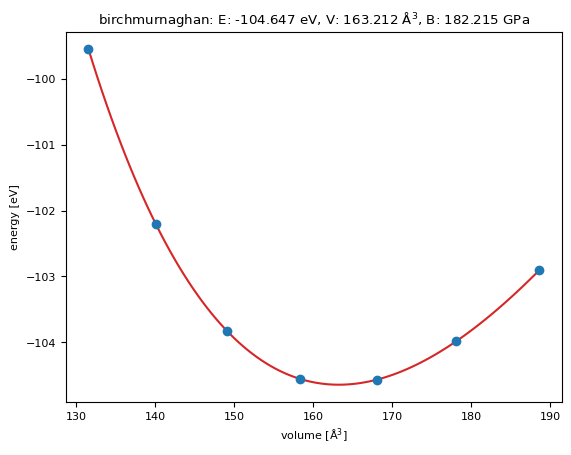

In [7]:
# --- Fit EOS ---
eos = EquationOfState(volumes, energies, eos="birchmurnaghan")
v0, e0, B = eos.fit()

# --- Compute equilibrium lattice parameter ---
a0 = (v0) ** (1.0 / 3.0)

# Convert bulk modulus from eV/Å^3 to GPa
B_GPa = B * 160.21766208

# --- Print results ---
print(f"Equilibrium lattice constant a0: {a0:.4f} Å")
print(f"Equilibrium volume: {v0:.2f} Å³")
print(f"Equilibrium energy: {e0:.4f} eV")
print(f"Bulk modulus: {B_GPa:.2f} GPa")

# --- Write log file ---
with open("eos_results.log", "w") as f:
    f.write("Equation of State Results for CeO2 (MACE-MP)\n")
    f.write("===========================================\n")
    f.write(f"Equilibrium lattice constant (a0): {a0:.4f} Å\n")
    f.write(f"Equilibrium volume (V0):           {v0:.2f} Å³\n")
    f.write(f"Equilibrium energy (E0):           {e0:.4f} eV\n")
    f.write(f"Bulk modulus (B0):                 {B_GPa:.2f} GPa\n")

# --- Save EOS plot ---
eos.plot("eos_mace_ceo2.png")